# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [3]:
from IPython.display import display, HTML, IFrame
import pandas as pd
from pandas import merge

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [8]:
main_narratives = [
'Government shutdown impacts federal contractors and their operations.',
'Shutdown may delay government contract payments to companies.',
'Federal agencies suspend services affecting business operations.',
'Companies may face delays in regulatory approvals during shutdown.',
'Shutdown disrupts government procurement processes for suppliers.',
'Federal employee furloughs reduce government agency capacity.',
'Companies dependent on federal contracts experience revenue delays.',
'Shutdown may halt new government contract awards and bidding.',
'Regulatory agencies suspend non-essential functions affecting businesses.',
'Companies may need to adjust cash flow due to delayed federal payments.',
'Shutdown creates uncertainty for government-dependent industries.',
'Federal contractors may need to furlough employees during shutdown.',
'Companies may face compliance delays due to suspended agency operations.',
'Shutdown impacts companies requiring federal permits and licenses.',
'Government data releases and reports are suspended affecting market analysis.',
'Companies may experience supply chain disruptions from federal agency closures.',
'Shutdown delays federal inspections and certifications for businesses.',
'Tourism companies face reduced demand due to national park closures.',
'Airlines may experience operational challenges from FAA staff reductions.',
'Defense contractors face project delays and payment postponements.',
'Healthcare companies experience FDA approval delays during shutdown.',
'Companies may need contingency plans for extended government closures.',
'Shutdown affects companies relying on federal research and development funding.',
'Government shutdown creates market volatility and investor uncertainty.',
'Companies may reassess government contract dependency risks.',
'Shutdown impacts federal employee spending affecting local businesses.'
]
 
# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-12"
end_date = "2025-10-06"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'W'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

# Country Filter
country_coverage_news_filter = ["United States"]

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [9]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

## Run Narrative Mining

Execute the narrative mining processes for news:

In [14]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")


df = news_results["df_labeled"]

if country_coverage_news_filter:
    df = df[(df['Country Code'].isin(country_coverage_news_filter)) | (df['Entity Type'] == 'PEOP')]
    df = df.drop_duplicates(subset=['Entity', 'Sentence ID'], keep='first')
    df = df.reset_index(drop=True)
    
df.to_csv("news_results_labeled_gov_shutdown.csv", index=False)

Mining news narratives...


Querying OpenAI...: 100%|██████████| 4047/4047 [03:28<00:00, 19.41it/s]


✅ News mining completed successfully!


In [10]:
df = pd.read_csv("news_results_labeled_gov_shutdown.csv")
df_narrative_search = df.copy()
#df_narrative_search = news_results["df_labeled"]


In [11]:
df_narrative_search["Entity Type"].value_counts()

Entity Type
ORGA    2054
PLCE     711
COMP     443
PEOP     429
LAND      24
FCTY      12
Name: count, dtype: int64

In [12]:
df_sentence_unique = df_narrative_search.drop_duplicates(subset=["Sentence ID"]).reset_index(drop=True)
print(len(df_narrative_search))
print(len(df_sentence_unique))


3673
1858


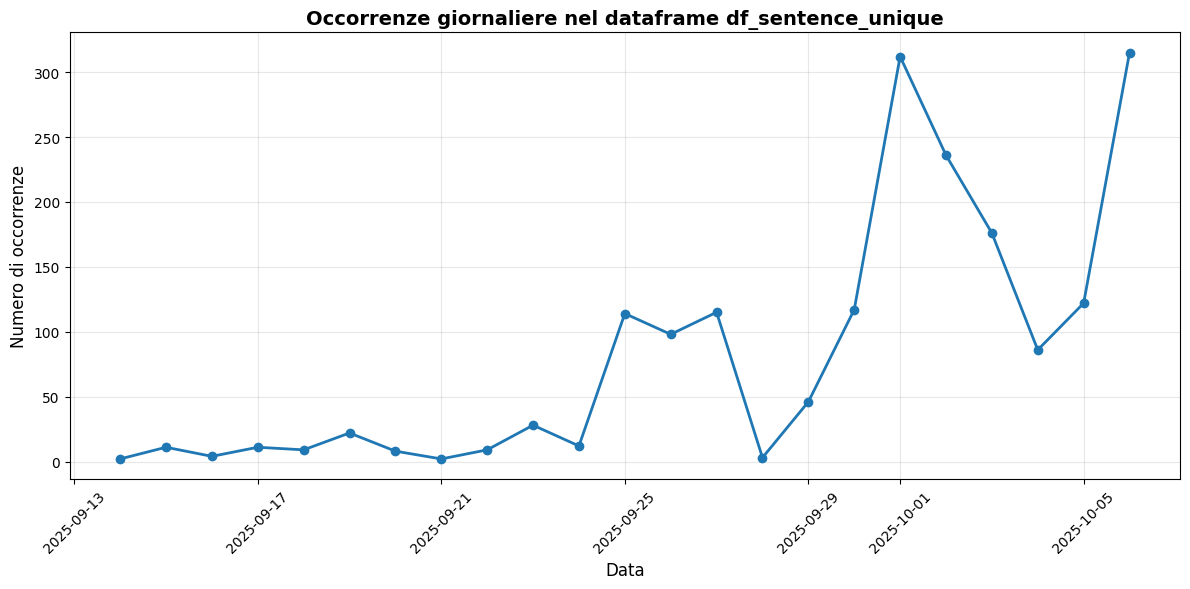

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Assicurati che la colonna Date sia in formato datetime
df_sentence_unique['Date'] = pd.to_datetime(df_sentence_unique['Date'])

# Conta le occorrenze per data
daily_counts = df_sentence_unique['Date'].value_counts().sort_index()

# Crea il plot
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2, markersize=6)
plt.title('Occorrenze giornaliere nel dataframe df_sentence_unique', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Numero di occorrenze', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Theme Match Labeling

This labeling step is to filter out the retrieved chunks that are not about the main_theme.

We only label the unique sentences, then the results are merged back to the original df.

In [14]:
from src.labeler.narrative_labeler import NarrativeLabeler
labeler = NarrativeLabeler(llm_model=llm_model)


In [15]:
df_sentence_unique_labeled = labeler.get_labels(
    main_theme="Government shutdown",
    texts=df_sentence_unique["Chunk Text"].tolist(),
    titles=df_sentence_unique["Headline"].tolist(),
    mode="theme_matching",
)

Querying OpenAI...:   0%|          | 0/1858 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1858/1858 [01:18<00:00, 23.80it/s]


In [16]:
df_sentence_unique_labeled.rename(columns={"label": "Theme Matching Label", "motivation": "Theme Matching Motivation"}, inplace=True)
df_sentence_unique_labeled_merged = merge(df_sentence_unique, df_sentence_unique_labeled, left_index=True, right_index=True)

# Select columns from df_sentence_unique_labeled_filtered
columns_to_merge = df_sentence_unique_labeled_merged[['Sentence ID', 'Theme Matching Label', 'Theme Matching Motivation']]

# Merge with df on Sentence ID
df_sentences_merged = df.merge(columns_to_merge, on='Sentence ID', how='left')
df_sentences_related = df_sentences_merged[df_sentences_merged["Theme Matching Label"] != "unclear"]

df_sentences_related.to_csv("news_results_labeled_theme_matching.csv", index=False)



# Creating the DF

In [17]:
top_x_people = 5
dict_people = {}

df_people = df_sentences_related[df_sentences_related["Entity Type"] == "PEOP"].copy()

# Keep track of top people for full range (count unique Sentence IDs per person)
entity_sentence_counts = df_people.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
top_people_full_range = entity_sentence_counts.head(top_x_people).index.tolist()

# Get top people per day (count unique Sentence IDs per person per day)
top_people_per_day = {}
for date in df_people["Date"].unique():
    df_day = df_people[df_people["Date"] == date]
    entity_counts = df_day.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
    top_people_per_day[date] = entity_counts.head(top_x_people).index.tolist()

# Get all unique people from top_people_per_day only
all_top_people = set()
for people_list in top_people_per_day.values():
    all_top_people.update(people_list)

# Create dictionary with dataframes for each person in all_top_people
for person in all_top_people:
    df_person = df_sentences_related[df_sentences_related["Entity"] == person]
    # Keep only first occurrence of each unique Chunk Text
    df_person = df_person.drop_duplicates(subset="Chunk Text", keep="first")
    df_person = df_person.reset_index(drop=True)
    dict_people[person] = df_person

dict_people.keys()

dict_keys(['Mike Johnson', 'Clark Spengler Bellin', 'Thomas I. Barkin', 'Jerome Powell', 'James A. Bianco', 'Edward Moore Kennedy', 'Xi Jinping', 'Mitch McConnell', 'Barack Obama', 'Kamala Harris', 'Russell Vought', 'Mark M. Zandi', 'Bill Huizenga', 'Jennifer Garner', 'Scott Bessent', 'Elizabeth Warren', 'John Kennedy', 'Joni Ernst', 'Don Beyer', 'Chuck Schumer', 'Geoffrey Freeman', 'Elon Musk', 'Karthik Nagalingam', 'Chris Van Hollen', 'Jaret Seiberg', 'J. D. Vance', 'Angela Alsobrooks', 'Brooke Rollins', 'Karoline Leavitt', 'Ben Cardin', 'Richard Burr', 'Donald Trump', 'Joe Biden', 'Sean Duffy', 'Michelle W. Bowman'])

In [18]:
top_x_companies = 5
dict_companies = {}

df_companies = df_sentences_related[df_sentences_related["Entity Type"] == "COMP"].copy()

# Keep track of top companies for full range (count unique Sentence IDs per company)
entity_sentence_counts = df_companies.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
top_companies_full_range = entity_sentence_counts.head(top_x_companies).index.tolist()

# Get top companies per day (count unique Sentence IDs per company per day)
top_companies_per_day = {}
for date in df_companies["Date"].unique():
    df_day = df_companies[df_companies["Date"] == date]
    entity_counts = df_day.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
    top_companies_per_day[date] = entity_counts.head(top_x_companies).index.tolist()

# Get all unique companies from top_companies_per_day only
all_top_companies = set()
for company_list in top_companies_per_day.values():
    all_top_companies.update(company_list)

# Create dictionary with dataframes for each company in all_top_companies
for company in all_top_companies:
    df_company = df_sentences_related[df_sentences_related["Entity"] == company]
    # Keep only first occurrence of each unique Chunk Text
    df_company = df_company.drop_duplicates(subset="Chunk Text", keep="first")
    df_company = df_company.reset_index(drop=True)
    dict_companies[company] = df_company

dict_companies.keys()

dict_keys(['Accretive Capital LLC', 'Palantir Technologies Inc.', 'American Airlines Group Inc.', 'Carson Group Holdings LLC', 'Interactive Brokers Group Inc.', 'BETA Technologies Inc.', 'Dow Jones & Co. Inc.', 'Bloomberg Inc.', 'EY-Parthenon Co.', 'Parsons Corp.', 'CoinDesk Inc.', 'Bianco Research LLC', 'Meta Platforms Inc.', 'NVIDIA Corp.', 'A. M. Best Co. Inc.', 'CNBC LLC', 'Mercury Systems Inc.', 'American Broadcasting System Inc.', 'MarketWatch Inc.', 'Yahoo Inc.', 'CNN', 'Morgan Stanley Co.', 'Raymond James Financial Inc.', 'National Air Traffic Controllers Association', 'TechCrunch Inc.', 'Lockheed Martin Corp.', 'Tesla Inc.', 'CBS News Inc.', 'Center For Financial Research And Analysis LLC', 'Bakkt Holdings Inc.', 'Comerica Inc.', 'Carson Group', 'CarMax Inc.', 'Wells Fargo Investment Institute Inc.', 'Barchart.com Inc.', 'United Airlines Inc.', 'Southwest Airlines Co.', 'Kalshi Inc.', 'Delta Air Lines Inc.', 'Boeing Co.', 'SVB Leerink LLC', 'Automatic Data Processing Inc.', 'O

# LABELING

In [19]:
from src.labeler.screener_labeler import ScreenerLabelerFlex
from src.labeler.narrative_labeler import NarrativeSummarizerFlex

In [20]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler


In [21]:
labeler = NarrativeLabeler(llm_model=llm_model)

dict_people_entity_reference = {}

removed_count=0

for people in dict_people.keys():
    print(f"Processing {people}, {len(dict_people[people])} sentences")
    df_temp = dict_people[people].copy()
    df_entity_reference = labeler.get_labels(
        main_theme="United States Government Shutdown",
        texts=df_temp["Chunk Text"].tolist(),
        titles=df_temp["Headline"].tolist(),
        mode="entity_reference",
        entity_track=people
    )
    df_entity_reference.rename(columns={"label": "Entity Reference Label", "motivation": "Entity Reference Motivation"}, inplace=True)
    df_temp_merged = merge(df_temp, df_entity_reference, left_index=True, right_index=True)
    df_temp_merged = df_temp_merged[df_temp_merged['Entity Reference Label'].isin(['DIRECT', 'MENTION'])]
    df_temp_merged = df_temp_merged.reset_index(drop=True)
    print(f"Kept {len(df_temp_merged)} and removed {len(df_temp) - len(df_temp_merged)}")
    removed_count+=len(df_temp) - len(df_temp_merged)
    dict_people_entity_reference[people] = df_temp_merged

print(f"Removed {removed_count} sentences")

Processing Mike Johnson, 5 sentences


Querying OpenAI...:   0%|          | 0/5 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


Kept 5 and removed 0
Processing Clark Spengler Bellin, 1 sentences


Querying OpenAI...: 100%|██████████| 1/1 [00:01<00:00,  1.39s/it]


...

Kept 7 and removed 0
Processing Sean Duffy, 6 sentences


Querying OpenAI...: 100%|██████████| 6/6 [00:02<00:00,  2.62it/s]


Kept 6 and removed 0
Processing Michelle W. Bowman, 3 sentences


Querying OpenAI...: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]

Kept 2 and removed 1
Removed 34 sentences


In [22]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [23]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o-mini")

import json

dict_people_summaries = {}

for people in dict_people_entity_reference.keys():
    df_person = pd.DataFrame()
    print(f"Processing {people}, {len(dict_people_entity_reference[people])} sentences")
    date_list = dict_people_entity_reference[people]["Date"].unique().tolist()
    for date in date_list:
        df_temp = dict_people_entity_reference[people][dict_people_entity_reference[people]["Date"] == date].copy()
        df_temp["Daily Summary"] = None
        df_temp["Daily Key Points"] = None
        daily_recap = narrative_summarizer.get_summaries(
            main_theme="United States Government Shutdown",
            df=df_temp,
            mode="companies_impact", 
            entity_track=people,
        )
        summary = daily_recap["summary"].iloc[0]
        key_points = daily_recap["key_points"].iloc[0]
        # Serializza key_points come stringa JSON per evitare problemi di salvataggio
        key_points_serialized = json.dumps(key_points, ensure_ascii=False)
        df_temp["Daily Summary"] = summary
        df_temp["Daily Key Points"] = key_points_serialized
        df_person = pd.concat([df_person, df_temp])
    dict_people_summaries[people] = df_person


Processing Mike Johnson, 5 sentences
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries and tracking key events about 'United States Government Shutdown'.
Your task is to analyze multiple piece chunks of text coming from news for a single entity about a single day.
The entity can be a company or a person.

You will receive entity data including:
- Entity name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the entity is positioned regarding the 'United States Government Shutdown'.
The summary should be a concise highlight with 'Mike Johnson' as the main subject, clearly explaining how the entity is positioned within the 'United States Government Shutdown' narrative - direct and focused, without adding unnecessary details.

Your second task is to create a prioritized list of key events and statements that track what happens to, wha

Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.35s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries and tracking key events about 'United States Government Shutdown'.
Your task is to analyze multiple piece chunks of text coming from news for a single entity about a single day.
The entity can be a company or a person.

You will receive entity data including:
- Entity name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the entity is positioned regarding the 'United States Government Shutdown'.
The summary should be a concise highlight with 'Mike Johnson' as the main subject, clearly explaining how the entity is positioned within the 'United States Government Shutdown' narrative - direct and focused, without adding unnecessary details.

Your second task is to create a prioritized list of key events and statements that track what happens to, what is said by, and what impacts 'Mike 


Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.77s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries and tracking key events about 'United States Government Shutdown'.
Your task is to analyze multiple piece chunks of text coming from news for a single entity about a single day.
The entity can be a company or a person.

You will receive entity data including:
- Entity name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the entity is positioned regarding the 'United States Government Shutdown'.
The summary should be a concise highlight with 'Mike Johnson' as the main subject, clearly explaining how the entity is positioned within the 'United States Government Shutdown' narrative - direct and focused, without adding unnecessary details.

Your second task is to create a prioritized list of key events and statements that track what happens to, what is said by, and what impacts 'Mike 

...


Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]

Processing Michelle W. Bowman, 2 sentences
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries and tracking key events about 'United States Government Shutdown'.
Your task is to analyze multiple piece chunks of text coming from news for a single entity about a single day.
The entity can be a company or a person.

You will receive entity data including:
- Entity name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the entity is positioned regarding the 'United States Government Shutdown'.
The summary should be a concise highlight with 'Michelle W. Bowman' as the main subject, clearly explaining how the entity is positioned within the 'United States Government Shutdown' narrative - direct and focused, without adding unnecessary details.

Your second task is to create a prioritized list of key events and statements that track what hap


Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.63s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries and tracking key events about 'United States Government Shutdown'.
Your task is to analyze multiple piece chunks of text coming from news for a single entity about a single day.
The entity can be a company or a person.

You will receive entity data including:
- Entity name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the entity is positioned regarding the 'United States Government Shutdown'.
The summary should be a concise highlight with 'Michelle W. Bowman' as the main subject, clearly explaining how the entity is positioned within the 'United States Government Shutdown' narrative - direct and focused, without adding unnecessary details.

Your second task is to create a prioritized list of key events and statements that track what happens to, what is said by, and what impacts 


Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


In [24]:
dict_people_summaries["Donald Trump"]


,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points
0,Sep 2025,2025-09-19,425678FD0C20BEF2F85395D86DA31DD6,425678FD0C20BEF2F85395D86DA31DD6-10,Government shutdown looms after Senate rejects...,"""If Senate Democrats insist on a Schumer Shutd...",The sentence discusses concerns among Democrat...,Federal employee furloughs reduce government a...,Donald Trump,NaN,PEOP,related,The sentence discusses the potential consequen...,Donald Trump is mentioned in the context of co...,MENTION,Donald Trump has been vocal about the United S...,"[""Stated willingness to take responsibility fo..."
1,Sep 2025,2025-09-20,49511B468E6AB9524CFC06BC8899C33A,49511B468E6AB9524CFC06BC8899C33A-6,Wall Street closes higher with indexes notchin...,"""Small caps have been trading inversely with r...",The sentence discusses the Senate blocking a s...,Government shutdown impacts federal contractor...,Donald Trump,NaN,PEOP,related,The sentence mentions the Senate blocking a sh...,Donald Trump is mentioned in the context of a ...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated willingness to accept a government sh..."
2,Sep 2025,2025-09-20,FB8B0B57C14B470592505DCCAE1ED79A,FB8B0B57C14B470592505DCCAE1ED79A-4,Global Stocks Climb as Central Banks Cut Inter...,Geopolitical developments also shaped sentimen...,The sentence discusses a failed Senate vote to...,Government shutdown impacts federal contractor...,Donald Trump,NaN,PEOP,related,The sentence discusses a failed Senate vote to...,Donald Trump is mentioned as the U.S. Presiden...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated willingness to accept a government sh..."
3,Sep 2025,2025-09-22,10A4BC54B4C1B849E23BD9E6239362DC,10A4BC54B4C1B849E23BD9E6239362DC-3,The stock market usually doesn't care about go...,"Karthik Nagalingam, U.S. credit strategist at ...",The sentence discusses the potential negative ...,Government shutdown creates market volatility ...,Donald Trump,NaN,PEOP,related,The sentence discusses the potential economic ...,Donald Trump is mentioned in the context of co...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated he will not back down on demands for ..."
4,Sep 2025,2025-09-22,64608C0189467FB84A5B21A2BD0FD3A0,64608C0189467FB84A5B21A2BD0FD3A0-4,S&amp;P 500 hit a new record after Nvidia anno...,Washington gridlock threatens market momentum\...,The sentence discusses the potential for a gov...,Government shutdown creates market volatility ...,Donald Trump,NaN,PEOP,related,The sentence discusses the risk of a governmen...,Donald Trump is mentioned as President in the ...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated he will not back down on demands for ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Oct 2025,2025-10-06,C871FEB9D749899642F0594E5AA2E4F2,C871FEB9D749899642F0594E5AA2E4F2-8,Q&A of the Day - How Much of the Federal Gover...,Environmental Protection Agency: 89%\nWhat we'...,The sentence discusses the impact of the Trump...,Federal employee furloughs reduce government a...,Donald Trump,NaN,PEOP,related,The sentence discusses the impact of the Trump...,Donald Trump is mentioned in relation to the a...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated he will not back down on demands for ..."
153,Oct 2025,2025-10-06,D30C52C2115DABEE0F5845FB427DF7B1,D30C52C2115DABEE0F5845FB427DF7B1-3,California Signs Law Granting State Agency Aut...,AB 288 arrives at a time where there is still ...,The sentence discusses the impact of the feder...,Federal agencies suspend services affecting bu...,Donald Trump,NaN,PEOP,related,The sentence discusses the impact of a federal...,Donald Trump is mentioned in relation to his n...,MENTION,Donald Trump is actively engaged in the narrat...,"[""Stated 

In [26]:
dict_people_summaries["Scott Bessent"]

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points
0,Oct 2025,2025-10-02,AD66CC81C0CFB0F8C51CF76E7BE95463,AD66CC81C0CFB0F8C51CF76E7BE95463-8,Treasury Secretary Scott Bessent warns governm...,Bessent's comments add to the pressure on lawm...,The sentence discusses the uncertainty created...,Shutdown creates uncertainty for government-de...,Scott Bessent,NaN,PEOP,related,The sentence discusses the impact of the gover...,Scott Bessent's comments are mentioned as cont...,MENTION,Scott Bessent has expressed significant concer...,"[""Warned that prolonged government shutdowns c..."
1,Oct 2025,2025-10-02,AD66CC81C0CFB0F8C51CF76E7BE95463,AD66CC81C0CFB0F8C51CF76E7BE95463-1,Treasury Secretary Scott Bessent warns governm...,Treasury Secretary Scott Bessent warned the go...,The sentence discusses the potential negative ...,Shutdown creates uncertainty for government-de...,Scott Bessent,NaN,PEOP,related,The sentence discusses the potential negative ...,Scott Bessent directly warned about the potent...,DIRECT,Scott Bessent has expressed significant concer...,"[""Warned that prolonged government shutdowns c..."
2,Oct 2025,2025-10-03,76B0CE5E5E31D94819EFA12AE2992998,76B0CE5E5E31D94819EFA12AE2992998-1,There's no stopping the U.S. stock markets,"Investors continue to pile into stocks, undete...",The sentence discusses how investors are react...,Government shutdown creates market volatility ...,Scott Bessent,NaN,PEOP,related,The sentence discusses the impact of a governm...,Scott Bessent directly states that economic gr...,DIRECT,Scott Bessent is actively engaged in discussio...,"[""Expressed concerns about the economic reperc..."
3,Oct 2025,2025-10-05,8EE4EA30798A09AD22A03AF65088BAF6,8EE4EA30798A09AD22A03AF65088BAF6-1,What to Expect in Markets This Week: Shutdown-...,Investors may not have as much to watch for th...,The sentence discusses the impact of the feder...,Government data releases and reports are suspe...,Scott Bessent,NaN,PEOP,related,The sentence discusses the implications of a f...,Scott Bessent is mentioned as a Treasury Secre...,MENTION,Scott Bessent is actively engaged in discussio...,"[""Expressed concern about the economic impact ..."
4,Oct 2025,2025-10-06,156B887DC5DC227E484F2E152C2CBBD0,156B887DC5DC227E484F2E152C2CBBD0-3,"FX Market Awaits Powell, As Government Shutdow...","The U.S. government shutdown, which began at m...",The sentence discusses the suspension of opera...,Federal agencies suspend services affecting bu...,Scott Bessent,NaN,PEOP,related,The sentence explicitly discusses the U.S. gov...,Scott Bessent warned that GDP growth could tak...,MENTION,Scott Bessent has expressed significant concer...,"[""Expressed concerns about the economic impact..."


Create unique dataframe with Entities - Summaries

In [27]:
all_dataframes = list(dict_people_summaries.values())
df_people_summaries = pd.concat(all_dataframes, ignore_index=True)
df_final_entity_summaries = df_people_summaries.drop_duplicates(subset=['Entity', 'Date'], keep='first')
df_final_entity_summaries

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points
0,Sep 2025,2025-09-19,6170199D546226AE5B2CDC66AA7B598C,6170199D546226AE5B2CDC66AA7B598C-7,"In Shutdown Battle, Dems Not Shy About Demands",A shutdown could lead to federal employees not...,The sentence discusses the potential consequen...,Federal employee furloughs reduce government a...,Mike Johnson,NaN,PEOP,related,The sentence discusses the potential consequen...,Mike Johnson directly quotes his statement reg...,DIRECT,Mike Johnson is actively engaged in the discus...,"[""Emphasized the importance of bipartisan coop..."
1,Sep 2025,2025-09-30,76734D7BCEBD2BAEEE6884E94F9D12D0,76734D7BCEBD2BAEEE6884E94F9D12D0-3,US government barrels toward shutdown with no ...,""" House of Representatives Speaker Mike Johnso...",The sentence discusses the potential closure o...,Federal agencies suspend services affecting bu...,Mike Johnson,NaN,PEOP,related,The sentence discusses the necessity of keepin...,Mike Johnson is directly quoted as saying that...,DIRECT,Mike Johnson is actively engaged in the discus...,"[""Emphasized the need for bipartisan negotiati..."
2,Oct 2025,2025-10-05,CF06480CCD823FBBA6D35B7CC3DFF12E,CF06480CCD823FBBA6D35B7CC3DFF12E-18,Government Shutdown Enters Fifth Day as Democr...,"""Johnson's not serious about this,"" Senate Dem...",The sentence discusses the ongoing government ...,Federal employee furloughs reduce government a...,Mike Johnson,NaN,PEOP,related,The sentence discusses the ongoing government ...,Mike Johnson is mentioned indirectly through t...,MENTION,Mike Johnson is actively engaged in the discus...,"[""Emphasized the need for bipartisan cooperati..."
3,Oct 2025,2025-10-06,050D9F619E94660C846983680340FDE9,050D9F619E94660C846983680340FDE9-19,Trump blames Democrats for federal layoffs as ...,"Johnson's not serious about this, Senate Democ...",The sentence discusses the ongoing government ...,Federal employee furloughs reduce government a...,Mike Johnson,NaN,PEOP,related,The sentence discusses the ongoing government ...,Mike Johnson is mentioned in the context of a ...,MENTION,Mike Johnson is actively engaged in the discus...,"[""Emphasized the need for bipartisan negotiati..."
5,Sep 2025,2025-09-26,C3C83D44C5C8CB1C28E4496DB1BFF406,C3C83D44C5C8CB1C28E4496DB1BFF406-19,Stocks Climb as Price Data Keep Fed Bets in Pl...,"""The looming government shutdown may spark sho...",The sentence discusses the potential for short...,Government shutdown creates market volatility ...,Clark Spengler Bellin,NaN,PEOP,related,The sentence discusses the potential impact of...,Clark Spengler Bellin directly quotes his stat...,DIRECT,Clark Spengler Bellin is actively engaged in d...,"[""Expressed concerns about the negative impact..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,Oct 2025,2025-10-04,C14AD6DD13BBECCFCB20575C93FF54A7,C14AD6DD13BBECCFCB20575C93FF54A7-2,Who gets back pay and who doesn't after a gove...,Such employees are by law entitled to back pay...,The sentence discusses the impact of a governm...,Government shutdown impacts federal contractor...,Joe Biden,NaN,PEOP,related,The sentence discusses the implications of a g...,Joe Biden is mentioned in the context of his f...,MENTION,Joe Biden is actively engaged in addressing th...,"[""Emphasized the need for bipartisan cooperati..."
249,Oct 2025,2025-10-06,73ACA3931B8C7836C341B49F9AE71C67,73ACA3931B8C7836C341B49F9AE71C67-21,MCAA Government Affairs Update for the Week of...,A small number of EPA staff would remain on ha...,The sentence discusses the continuation of cer...,Shutdown impacts companies requiring federal p...,Joe Biden,NaN,PEOP,related,The sentence discusses the operations of vario...,Joe Biden is mentioned in relation to the Infl...,MENTION,Joe Biden is actively engaged in addressing th...,"[""E

In [ ]:
dict_people_summaries["Scott Bessent"]

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points
0,Oct 2025,2025-10-02,AD66CC81C0CFB0F8C51CF76E7BE95463,AD66CC81C0CFB0F8C51CF76E7BE95463-8,Treasury Secretary Scott Bessent warns governm...,Bessent's comments add to the pressure on lawm...,The sentence discusses the uncertainty created...,Shutdown creates uncertainty for government-de...,Scott Bessent,NaN,PEOP,related,The sentence discusses the impact of the gover...,Scott Bessent's comments are mentioned as cont...,MENTION,Scott Bessent has expressed significant concer...,"[""Warned that prolonged government shutdowns c..."
1,Oct 2025,2025-10-02,AD66CC81C0CFB0F8C51CF76E7BE95463,AD66CC81C0CFB0F8C51CF76E7BE95463-1,Treasury Secretary Scott Bessent warns governm...,Treasury Secretary Scott Bessent warned the go...,The sentence discusses the potential negative ...,Shutdown creates uncertainty for government-de...,Scott Bessent,NaN,PEOP,related,The sentence discusses the potential negative ...,Scott Bessent directly warned about the potent...,DIRECT,Scott Bessent has expressed significant concer...,"[""Warned that prolonged government shutdowns c..."
2,Oct 2025,2025-10-03,76B0CE5E5E31D94819EFA12AE2992998,76B0CE5E5E31D94819EFA12AE2992998-1,There's no stopping the U.S. stock markets,"Investors continue to pile into stocks, undete...",The sentence discusses how investors are react...,Government shutdown creates market volatility ...,Scott Bessent,NaN,PEOP,related,The sentence discusses the impact of a governm...,Scott Bessent directly states that economic gr...,DIRECT,Scott Bessent is actively engaged in discussio...,"[""Expressed concerns about the economic reperc..."
3,Oct 2025,2025-10-05,8EE4EA30798A09AD22A03AF65088BAF6,8EE4EA30798A09AD22A03AF65088BAF6-1,What to Expect in Markets This Week: Shutdown-...,Investors may not have as much to watch for th...,The sentence discusses the impact of the feder...,Government data releases and reports are suspe...,Scott Bessent,NaN,PEOP,related,The sentence discusses the implications of a f...,Scott Bessent is mentioned as a Treasury Secre...,MENTION,Scott Bessent is actively engaged in discussio...,"[""Expressed concern about the economic impact ..."
4,Oct 2025,2025-10-06,156B887DC5DC227E484F2E152C2CBBD0,156B887DC5DC227E484F2E152C2CBBD0-3,"FX Market Awaits Powell, As Government Shutdow...","The U.S. government shutdown, which began at m...",The sentence discusses the suspension of opera...,Federal agencies suspend services affecting bu...,Scott Bessent,NaN,PEOP,related,The sentence explicitly discusses the U.S. gov...,Scott Bessent warned that GDP growth could tak...,MENTION,Scott Bessent has expressed significant concer...,"[""Expressed concerns about the economic impact..."


In [83]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [91]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o-mini")

# Generic dataframe assignment - modify this line to switch between different dataframes
#df_input = df_final_entity_summaries[df_final_entity_summaries["Entity"] == "Scott Bessent"].copy()
df_input = df_final_entity_summaries.copy()

# Initialize enhanced columns in the dataframe
df_input["enhanced_summary"] = None
df_input["enhanced_key_points"] = None

# Sort by Entity and Date
df_input = df_input.sort_values(['Entity', 'Date'])

# Initialize global dictionary for previous narratives
previous_narrative_dict = {}

# Get unique entities and process each entity across all its dates
for entity_name in df_input['Entity'].unique():
    entity_df = df_input[df_input['Entity'] == entity_name].copy()
    
    # Sort by date (should already be sorted, but just to be sure)
    entity_df = entity_df.sort_values('Date')
    
    # Get unique dates for this entity
    dates = sorted(entity_df["Date"].unique())
    
    # Variables to track summaries for consolidation
    iteration_summaries = {}  # Store summary for each iteration
    consolidated_narrative = None
    
    # Process each date for this entity
    for iteration, date in enumerate(dates):
        df_temp = entity_df[entity_df["Date"] == date]
        string_date = f"Date: {str(date)}"

        print(f"Processing Entity: {entity_name}, Date: {date}, Iteration: {iteration}")
        
        if iteration == 0:
            # First iteration: skip, use only existing summary
            print("First iteration - skipping get_summaries, using existing summary")
            
            # Take existing summary as baseline
            existing_summary = df_temp["Daily Summary"].iloc[0] if "Daily Summary" in df_temp.columns else ""
            existing_key_points = df_temp["Daily Key Points"].iloc[0] if "Daily Key Points" in df_temp.columns else []
            
            # Ensure key_points is a list
            if not isinstance(existing_key_points, list):
                existing_key_points = [str(existing_key_points)] if existing_key_points else []
            
            # Save to dataframe (use .at to assign list to single cell)
            mask = (df_input["Entity"] == entity_name) & (df_input["Date"] == date)
            row_index = df_input[mask].index[0]
            df_input.at[row_index, "enhanced_summary"] = existing_summary
            df_input.at[row_index, "enhanced_key_points"] = existing_key_points
            
            # Store iteration 0 summary (convert to string for consolidation purposes)
            key_points_str = "\n".join(existing_key_points) if existing_key_points else ""
            iteration_summaries[0] = string_date + " \n " + existing_summary + " \n " + key_points_str
            consolidated_narrative = iteration_summaries[0]
            
        elif iteration == 1:
            # Second iteration: only temporal analysis with previous narrative
            print("Second iteration - temporal analysis only")
            
            # Prepare previous narrative for temporal analysis
            entity_previous_narrative = {f"{entity_name}_{dates[0]}": consolidated_narrative}

            print("-\n\n\n-Input for temporal analysis iteration 1:")
            print("entity_previous_narrative:", entity_previous_narrative)
            print("Summary:", df_temp["Daily Summary"].iloc[0])
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Government shutdown",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",
                entity_track=entity_name,
                previous_narrative=entity_previous_narrative
            )

            print("-\n\n\n-Output from temporal analysis iteration 1:")
            print("daily_recap:", daily_recap["summary"].iloc[0])
            print("daily_recap key points:", daily_recap["key_points"].iloc[0])
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            
            # Process results
            for _, recap_row in daily_recap.iterrows():
                recap_entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_input["Entity"] == entity_name) & (df_input["Date"] == date)
                row_index = df_input[mask].index[0]
                df_input.at[row_index, "enhanced_summary"] = summary
                df_input.at[row_index, "enhanced_key_points"] = key_points
                
                # Store iteration 1 summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[1] = summary + "\n" + key_points_str
                
        else:
            # Third iteration and beyond: consolidate then do temporal analysis
            print(f"Iteration {iteration} - consolidation + temporal analysis")

            # Step 1: Extract new information to append
            # For iteration 2: previous = iteration 0, today = iteration 1
            # For iteration 3+: previous = consolidated from previous step, today = previous iteration
            if iteration == 2:
                previous_summary_for_consolidation = iteration_summaries[0]
                today_summary_for_consolidation = iteration_summaries[1]
            else:
                previous_summary_for_consolidation = consolidated_narrative
                today_summary_for_consolidation = iteration_summaries[iteration - 1]

            print(f"Consolidating: previous from iteration {0 if iteration == 2 else 'consolidated'}, today from iteration {iteration - 1}")
            
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            print("-\n\n\n-Input for consolidation:")
            print("previous_summary_for_consolidation:", previous_summary_for_consolidation)
            print("today_summary_for_consolidation:", today_summary_for_consolidation)
            new_daily_narrative = narrative_summarizer.get_summaries(
                main_theme="Government shutdown",
                mode="company_narrative_consolidation",
                previous_summary=previous_summary_for_consolidation,
                today_summary=today_summary_for_consolidation,
                entity_track=entity_name,
            )
            print("-\n\n\n-Output from consolidation:")
            print("new_daily_narrative to add:", new_daily_narrative)
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            # Manually concatenate previous summary with new information
            if new_daily_narrative and new_daily_narrative.strip():
                consolidated_narrative = previous_summary_for_consolidation + " \n " + string_date + " \n " + new_daily_narrative
            else:
                # If no new information, keep the previous summary as is
                consolidated_narrative = previous_summary_for_consolidation
            

            print(f"New daily narrative length: {len(new_daily_narrative) if new_daily_narrative else 0}")
            print(f"Consolidated narrative length: {len(consolidated_narrative) if consolidated_narrative else 0}")
            print("*************")
            # Step 2: Apply temporal analysis with consolidated summary
            entity_previous_narrative = {f"{entity_name}_consolidated": consolidated_narrative}
            
            print("-\n\n\n-Input for temporal analysis iteration 2+:")
            print("entity_previous_narrative:", entity_previous_narrative)
            print("Summary:", df_temp["Daily Summary"].iloc[0])
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Government shutdown",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",
                entity_track=entity_name,
                previous_narrative=entity_previous_narrative
            )

            print("-\n\n\n-Output from temporal analysis iteration 2+:")
            print("daily_recap:", daily_recap["summary"].iloc[0])
            print("daily_recap key points:", daily_recap["key_points"].iloc[0])
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            # Process results
            for _, recap_row in daily_recap.iterrows():
                recap_entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_input["Entity"] == entity_name) & (df_input["Date"] == date)
                row_index = df_input[mask].index[0]
                df_input.at[row_index, "enhanced_summary"] = summary
                df_input.at[row_index, "enhanced_key_points"] = key_points
                
                # Store current iteration summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[iteration] = summary + "\n" + key_points_str
        


# Save results
df_input.to_csv("entity_summaries_enhanced.csv", index=False)

Processing Entity: Angela Alsobrooks, Date: 2025-10-03, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Ben Cardin, Date: 2025-09-25, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Bill Huizenga, Date: 2025-09-19, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Brooke Rollins, Date: 2025-10-05, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Chris Van Hollen, Date: 2025-09-25, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Chris Van Hollen, Date: 2025-10-03, Iteration: 1
Second iteration - temporal analysis only
-


-Input for temporal analysis iteration 1:
entity_previous_narrative: {'Chris Van Hollen_2025-09-25': 'Date: 2025-09-25 \n Chris Van Hollen is actively engaged in discussions surrounding the United States Government Shutdown, emphas

Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it]

-


-Output from temporal analysis iteration 1:
daily_recap: Chris Van Hollen has called for immediate action to ensure government operations continue without interruption, highlighting the urgency of the situation amid ongoing discussions about the government shutdown.
daily_recap key points: ['Called for immediate action to ensure government operations continue without interruption', 'Criticized the potential economic impacts of a government shutdown']
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Processing Entity: Chuck Schumer, Date: 2025-09-19, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Chuck Schumer, Date: 2025-09-22, Iteration: 1
Second iteration - temporal analysis only
-


-Input for temporal analysis iteration 1:
entity_previous_narrative: {'Chuck Schumer_2025-09-19': 'Date: 2025-09-19 \n Chuck Schumer is actively engaged in the discussi


Querying OpenAI...: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


...

-


-Output from consolidation:
new_daily_narrative to add: 
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
New daily narrative length: 0
Consolidated narrative length: 1206
*************
-


-Input for temporal analysis iteration 2+:
entity_previous_narrative: {'Scott Bessent_consolidated': 'Date: 2025-10-02 \n Scott Bessent has expressed significant concerns regarding the potential impacts of the United States Government Shutdown on economic stability and market confidence. He has highlighted the importance of timely government operations to maintain investor trust and has warned that prolonged shutdowns could lead to adverse effects on the economy. His statements reflect a proactive stance on the need for resolution to avoid negative repercussions for both businesses and the broader financial landscape. \n ["Warned that prolonged government shutdowns could adversely affect economic stability and inv


Querying OpenAI...: 100%|██████████| 1/1 [00:01<00:00,  1.92s/it]

-


-Output from temporal analysis iteration 2+:
daily_recap: Scott Bessent has reiterated his concerns about the economic impacts of a prolonged government shutdown, emphasizing the risks associated with uncertainty and the need for timely resolution to avoid detrimental effects on businesses and consumers.
daily_recap key points: ['Expressed concerns about the economic impacts of a prolonged government shutdown', 'Highlighted risks associated with uncertainty during the shutdown']
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Processing Entity: Sean Duffy, Date: 2025-09-30, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Thomas I. Barkin, Date: 2025-09-26, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Processing Entity: Thomas I. Barkin, Date: 2025-09-27, Iteration: 1
Second iteration - temporal analysis only
-


-Input


Querying OpenAI...: 100%|██████████| 1/1 [00:01<00:00,  1.48s/it]

-


-Output from temporal analysis iteration 1:
daily_recap: No new developments. Today's information reiterates previous concerns expressed by Thomas I. Barkin regarding the potential impacts of a government shutdown on the economy.
daily_recap key points: []
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Processing Entity: Xi Jinping, Date: 2025-09-20, Iteration: 0
First iteration - skipping get_summaries, using existing summary


In [92]:
df_input

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points,enhanced_summary,enhanced_key_points
79,Oct 2025,2025-10-03,89F6ED795B0D8A1CCF730566BC324F86,89F6ED795B0D8A1CCF730566BC324F86-8,"Amid Government Shutdown, Sen. Smith, Rep. Pre...","Just like civil servants, federal contractors ...",The sentence discusses the need for federal co...,Government shutdown impacts federal contractor...,Angela Alsobrooks,NaN,PEOP,related,The sentence discusses the Fair Pay for Federa...,Angela Alsobrooks directly quotes a statement ...,DIRECT,Angela Alsobrooks has been vocal about the imp...,"[""Expressed concern over the potential disrupt...",Angela Alsobrooks has been vocal about the imp...,"[[""Expressed concern over the potential disrup..."
83,Sep 2025,2025-09-25,37DB91F256BBF4661F71627783285F7B,37DB91F256BBF4661F71627783285F7B-13,"Government shutdown, mass firings loom with no...","""These federal workers maybe, for a period of ...",The sentence discusses how federal workers not...,Shutdown impacts federal employee spending aff...,Ben Cardin,NaN,PEOP,related,The sentence discusses the impact of federal w...,Ben Cardin directly quotes his statement about...,DIRECT,Ben Cardin has been vocal about the implicatio...,"[""Criticized the lack of progress in negotiati...",Ben Cardin has been vocal about the implicatio...,"[[""Criticized the lack of progress in negotiat..."
44,Sep 2025,2025-09-19,ECC3B50E8300457EDD29FCB232B45A2E,ECC3B50E8300457EDD29FCB232B45A2E-2,"Huizenga bill would pay immigration agents, Co...",The bill arrives as the federal government is ...,The sentence discusses a bill aimed at ensurin...,Government shutdown impacts federal contractor...,Bill Huizenga,NaN,PEOP,related,The sentence discusses the impending governmen...,Bill Huizenga's bill is mentioned as a specifi...,MENTION,Bill Huizenga is actively engaged in discussio...,"[""Emphasized the need for fiscal responsibilit...",Bill Huizenga is actively engaged in discussio...,"[[""Emphasized the need for fiscal responsibili..."
80,Oct 2025,2025-10-05,C39F72D15170AB9DC7CCCA8651F39741,C39F72D15170AB9DC7CCCA8651F39741-4,Government Shutdown: Cancellations and Postpon...,"Reports due this week: Wellllllll, about that....",The sentence discusses the cancellation or pos...,Government data releases and reports are suspe...,Brooke Rollins,NaN,PEOP,related,The sentence discusses the impact of the gover...,Brooke Rollins is mentioned as the Ag Secretar...,MENTION,Brooke Rollins is actively engaged in discussi...,"[""Emphasized the importance of bipartisan coop...",Brooke Rollins is actively engaged in discussi...,"[[""Emphasized the importance of bipartisan coo..."
69,Sep 2025,2025-09-25,EB69F48CA090996C12E7B9EB45CA49D3,EB69F48CA090996C12E7B9EB45CA49D3-2,Senate progressive accuses Trump of 'mafia-sty...,"Sen. Chris Van Hollen, D-Md., railed against t...",The sentence discusses a memo from the Office ...,Federal employee furloughs reduce government a...,Chris Van Hollen,NaN,PEOP,related,The sentence discusses a memo from the Office ...,Chris Van Hollen railed against the OMB's memo...,MENTION,Chris Van Hollen is actively engaged in discus...,"[""Emphasized the need for bipartisan cooperati...",Chris Van Hollen is actively engaged in discus...,"[[""Emphasized the need for bipartisan cooperat..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,Oct 2025,2025-10-06,156B887DC5DC227E484F2E152C2CBBD0,156B887DC5DC227E484F2E152C2CBBD0-3,"FX Market Awaits Powell, As Government Shutdow...","The U.S. government shutdown, which began at m...",The sentence discusses the suspension of opera...,Federal agencies suspend services affecting bu...,Scott Bessent,NaN,PEOP,related,The sentence explicitly discusses the U.S. gov...,Scott Bessent warned that GDP growth could tak...,MENTION,Scott Bess

In [90]:
for _, row in df_input.iterrows():

    print("Daily Summary")
    print(row["Daily Summary"])
    print("Daily Key Points")
    print(row["Daily Key Points"])
    print("Enhanced Summary")
    print(row["enhanced_summary"])
    print("Enhanced Key Points")
    print(row["enhanced_key_points"])
    print("-" * 50)





Daily Summary
Scott Bessent has expressed significant concerns regarding the potential impacts of the United States Government Shutdown on economic stability and market confidence. He has highlighted the importance of timely government operations to maintain investor trust and has warned that prolonged shutdowns could lead to adverse effects on the economy. His statements reflect a proactive stance on the need for resolution to avoid negative repercussions for both businesses and the broader financial landscape.
Daily Key Points
["Warned that prolonged government shutdowns could adversely affect economic stability and investor confidence.", "Emphasized the necessity of timely government operations to maintain market trust.", "Criticized the potential for a shutdown to create uncertainty in the financial markets."]
Enhanced Summary
Scott Bessent has expressed significant concerns regarding the potential impacts of the United States Government Shutdown on economic stability and market co

In [42]:
new_daily_narrative = narrative_summarizer.get_summaries(
                main_theme="Government shutdown",
                mode="company_narrative_consolidation",
                previous_summary="Scott Bessent has expressed significant concerns regarding the potential impacts of the United States Government Shutdown on economic stability and market confidence. He has highlighted the importance of timely government operations to maintain investor trust and has warned that prolonged shutdowns could lead to adverse effects on the economy. His statements reflect a proactive stance on the need for resolution to avoid negative repercussions for both businesses and the broader financial landscape.",
                today_summary="Scott Bessent is actively engaged in discussions surrounding the United States Government Shutdown, emphasizing the potential economic repercussions and advocating for a resolution. He has expressed concerns about the negative impact on government operations and the broader economy, highlighting the urgency for bipartisan cooperation to prevent prolonged disruptions.",
                entity_track="Scott Bessent",
            )

DEBUG: CONSOLIDATION SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in identifying new informatio
DEBUG: CONSOLIDATION USER PROMPT
{"Previous Summary": "Scott Bessent has expressed significant concerns regarding the potential impacts of the United States Government Shutdown on economic stability and market confidence. He has highlighted the importance of timely government operations to maintain investor trust and has warned that prolonged shutdowns could lead to adverse effects on the economy. His statements reflect a proactive stance on the need for resolution to avoid negative repercussions for both businesses and the broader financial landscape.", "Today Summary": "Scott Bessent is actively engaged in discussions surrounding the United States Government Shutdown, emphasizing the potential economic repercussions and advocating for a resolution. He has expressed concerns about the negative impact on government operations and the broader economy, h

Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


In [43]:
new_daily_narrative

'Scott Bessent is actively engaged in discussions surrounding the United States Government Shutdown, emphasizing the potential economic repercussions and advocating for a resolution. He has expressed concerns about the negative impact on government operations and the broader economy, highlighting the urgency for bipartisan cooperation to prevent prolonged disruptions.'

In [38]:
df_company_summaries.to_csv("news_results_labeled_company_summaries.csv", index=False)

In [33]:
from src.report.html import generate_company_comparison_html

generate_company_comparison_html(df_company_summaries)

Company comparison HTML file saved as: company_comparison_report.html


'company_comparison_report.html'

## Generate Final Narrative for each of the Actors

In [34]:
df_temp_summaries = df_company_summaries.copy()

In [35]:
df_summaries_companies = df_company_summaries[["Entity", "Date", "enhanced_summary", "enhanced_key_points"]]
df_summaries_companies = df_summaries_companies.rename(columns={"enhanced_summary": "Summary", "enhanced_key_points": "Key Points"})
df_summaries_trump = df_DT_theme_matching_citation[["Entity", "Date", "daily summary", "daily bullet points"]]
df_summaries_trump = df_summaries_trump.drop_duplicates(subset=["Date"])
df_summaries_trump = df_summaries_trump.rename(columns={"daily summary": "Summary", "daily bullet points": "Key Points"})
df_summaries_entities = pd.concat([df_summaries_companies, df_summaries_trump], ignore_index=True)

In [ ]:
#df_summaries_entities.to_csv("df_summaries_entities.csv", index=False)

In [93]:
df_summaries_entities["Key Points"].iloc[63]

"On Friday, President Donald Trump's administration announced a $100,000 fee for all new recipients of H-1B visas, a type of nonimmigrant visa designed to help U.S. companies find employees with technical skills not common in the U.S.\nTrump argued that the fee will encourage companies to hire American workers, instead of foreign ones.\nThe Trump administration's sharp increase in visa fees for H-1B workers has triggered concern among US technology companies, with many considering moving more jobs overseas.\nTrump stated that 'abuse' of H-1B visas has facilitated an 'influx' of foreign labour in STEM that has undermined salaries and workplace conditions for US workers.\nThe fee hike sent H-1B holders into panic mode, prompting companies like Microsoft to ask employees abroad to rush back before midnight."

In [39]:
df_summaries_entities['Date'] = pd.to_datetime(df_summaries_entities['Date']).dt.strftime('%Y-%m-%d')


ValueError: time data "2025-09-19" doesn't match format "%Y-%m-%d %H:%M:%S", at position 58. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [53]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex

In [63]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
df_summaries_entities = df_summaries_entities.sort_values('Date')

    
# Get final recap
entities_final_summary = narrative_summarizer.get_summaries(
    main_theme="Introduction of a high fee on H-1B visas",
    df=df_summaries_entities,
    mode="final_summary_from_daily_summaries",
)



DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating a comprehensive final recap summary from daily summaries focused on the theme of 'Introduction of a high fee on H-1B visas'. Each daily summary is compiled from news articles that reference specific companies or individuals based on their strategic positioning, actions taken, or relationship to the main theme.
You have to create a final narrative summary that captures the most significant developments and insights from the daily summaries.

You are given:
    - Name of the company or individual
    - A series of dates and daily summaries

1. **Task**: 
    - You must create a final narrative summary that captures the most significant developments and insights from the daily summaries.
    - Do not include any information that is not related to the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
    - Do not add any information from your own knowledge or

Querying OpenAI...:   0%|          | 0/13 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 13/13 [00:07<00:00,  1.71it/s]


In [65]:
entities_final_summary.to_csv("final_summary_per_entity.csv", index=False)

In [135]:
entities_final_summary = pd.read_csv("final_summary_per_entity.csv")

In [41]:
# Versione più elegante con pandas groupby
countries_dict = df_company_summaries.groupby('Country')['Entity'].apply(list).to_dict()

# Rimuovi eventuali duplicati (se ci sono)
for country in countries_dict:
    countries_dict[country] = list(set(countries_dict[country]))


In [69]:
df_highlights = pd.DataFrame()
for country, companies in countries_dict.items():
    print("Processing companies:", companies)
    daily_highlights = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_summaries_entities,
        mode="companies_daily_highlights_from_daily_key_points",
        additional_parameters={"companies": companies}
    )
    df_highlights = pd.concat([df_highlights, daily_highlights], ignore_index=True)

Processing companies: ['Thomson Reuters Corp.', 'DBRS Ltd.', 'Talent Fund']


Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.22s/it]


Processing companies: ['IBM Corp. Pty. Ltd.', 'Metaview', 'Dewang']


Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.89s/it]


Processing companies: ['Tata Consultancy Services Ltd.', 'Infosys Ltd.', 'Wipro Ltd.']


Querying OpenAI...: 100%|██████████| 1/1 [00:09<00:00,  9.26s/it]


Processing companies: ['Amazon.com Inc.', 'Alphabet Inc.', 'Microsoft Corp.']


Querying OpenAI...: 100%|██████████| 1/1 [00:05<00:00,  5.19s/it]


In [70]:
df_highlights.to_csv("df_highlights.csv", index=False)

In [42]:
df_highlights = pd.read_csv("df_highlights.csv")

# CREATE VISUALIZATIONS

In [43]:
narrative_dates

array(['2025-09-19', '2025-09-20', '2025-09-21', '2025-09-22',
       '2025-09-23', '2025-09-24', '2025-09-25'], dtype=object)

In [147]:
df_company_summaries.head()

,Entity,Date,Summary,Key_points,Quotes,Country,enhanced_summary,enhanced_key_points
0,Alphabet Inc.,2025-09-19,Alphabet Inc. is positioned to face significan...,['The introduction of a high fee on H-1B visas...,"['For companies like Google, Microsoft, Amazon...",United States,Alphabet Inc. is positioned to face significan...,['The introduction of a high fee on H-1B visas...
1,Alphabet Inc.,2025-09-20,Alphabet Inc. is positioned to face significan...,"['The $100,000 annual fee on H-1B visas is exp...","['""US tech giants like Amazon, Microsoft, Goog...",United States,Alphabet Inc. is now facing the introduction o...,"['The introduction of a $100,000 annual fee on..."
2,Alphabet Inc.,2025-09-21,Alphabet Inc. is significantly impacted by the...,['Alphabet Inc. is concerned about the financi...,"[""Amazon, Alphabet's Google, Microsoft and oth...",United States,Alphabet Inc. is facing significant financial ...,['Alphabet Inc. is concerned about the financi...
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...","[""Alphabet Inc.'s Google employs thousands of ...","['In response to the announcement, tech giants...",United States,"Alphabet Inc., through its subsidiary Google, ...",['Alphabet Inc. employs thousands of H-1B visa...
4,Alphabet Inc.,2025-09-23,Alphabet Inc. is positioned as a significant p...,['Alphabet Inc. is among the tech giants that ...,"['For Silicon Valley, the decision is disrupti...",United States,New information indicates that Alphabet Inc. h...,['Alphabet Inc. has historically relied on H-1...


In [149]:
import importlib
import sys

# Force reload of the plots module
if 'src.report.plots' in sys.modules:
    importlib.reload(sys.modules['src.report.plots'])

# Import the function
from src.report.plots import create_enhanced_interactive_chart

# Create enhanced chart
fig_enhanced = create_enhanced_interactive_chart(
    df_DT_theme_matching_narrative, 
    df_DT_theme_matching_citation, 
    df_top_3_all_countries, 
    df_company_summaries, 
    narrative_dates
)

# Show the enhanced plot
fig_enhanced.show()

# Save with better name
fig_enhanced.write_html("h1b_narrative_dashboard_enhanced.html")
print("Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'")

Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'


In [94]:

# Forza reload
import importlib
import sys
if 'src.report.html' in sys.modules:
    importlib.reload(sys.modules['src.report.html'])
from src.report import html

html.generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    countries_dict=countries_dict,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    output_file="simple_interactive_timeline.html"
    # Nessun parametro follow_trend!
)

Interactive timeline dashboard generated: simple_interactive_timeline.html


'simple_interactive_timeline.html'

Interactive timeline dashboard generated: full_dashboard.html


'full_dashboard.html'

In [55]:
countries_dict

{'Canada': ['Thomson Reuters Corp.', 'DBRS Ltd.', 'Talent Fund'],
 'China': ['Metaview', 'IBM Corp. Pty. Ltd.', 'Dewang'],
 'India': ['Tata Consultancy Services Ltd.', 'Infosys Ltd.', 'Wipro Ltd.'],
 'United States': ['Microsoft Corp.', 'Amazon.com Inc.', 'Alphabet Inc.']}

In [50]:
df_sentences_related.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation'],
      dtype='object')

In [52]:
unique_documents_count = df_sentences_related['Document ID'].nunique()
unique_documents_count

1372

In [76]:
unique_sentences_count = df_sentences_related['Sentence ID'].nunique()
unique_sentences_count

2175

In [74]:
# Extract all companies from countries_dict
all_companies = []
for country, companies in countries_dict.items():
    all_companies.extend(companies)

# Calculate overall totals for each company first
overall_totals = {}
for company in all_companies:
    company_rows = df_sentences_related[df_sentences_related['Entity'] == company]
    overall_totals[company] = {
        'Overall_Total_Sentences': len(company_rows),
        'Overall_Unique_Documents': company_rows['Document ID'].nunique()
    }

# Get unique dates
unique_dates = df_sentences_related['Date'].unique()

# Calculate statistics for each company and date
company_data = []
for date in unique_dates:
    # Filter data for this specific date
    date_data = df_sentences_related[df_sentences_related['Date'] == date]
    total_unique_docs_date = date_data['Document ID'].nunique()
    
    for company in all_companies:
        company_rows = date_data[date_data['Entity'] == company]
        total_sentences = len(company_rows)
        unique_docs = company_rows['Document ID'].nunique()
        
        # Calculate overall percentage
        overall_percentage = round((overall_totals[company]['Overall_Unique_Documents'] / unique_documents_count * 100) if unique_documents_count > 0 else 0, 2)
        
        company_data.append({
            'Date': date,
            'Company': company,
            'Total_Sentences': total_sentences,
            'Unique_Documents': unique_docs,
            'Total_Unique_Documents': total_unique_docs_date,
            'Percentage_Documents': round((unique_docs / total_unique_docs_date * 100) if total_unique_docs_date > 0 else 0, 2),
            'Overall_Total_Sentences': overall_totals[company]['Overall_Total_Sentences'],
            'Overall_Unique_Documents': overall_totals[company]['Overall_Unique_Documents'],
            'Overall_Percentage_Documents': overall_percentage
        })

# Create final dataframe
company_stats = pd.DataFrame(company_data)
company_stats = company_stats.sort_values(['Date', 'Total_Sentences'], ascending=[True, False])

In [91]:
company_stats

,Date,Company,Total_Sentences,Unique_Documents,Total_Unique_Documents,Percentage_Documents,Overall_Total_Sentences,Overall_Unique_Documents,Overall_Percentage_Documents
9,2025-09-19,Microsoft Corp.,9,4,29,13.79,441,165,12.03
10,2025-09-19,Amazon.com Inc.,9,4,29,13.79,493,169,12.32
11,2025-09-19,Alphabet Inc.,7,2,29,6.90,327,98,7.14
4,2025-09-19,IBM Corp. Pty. Ltd.,4,1,29,3.45,19,10,0.73
7,2025-09-19,Infosys Ltd.,4,1,29,3.45,190,79,5.76
...,...,...,...,...,...,...,...,...,...
74,2025-09-25,Talent Fund,1,1,63,1.59,2,2,0.15
75,2025-09-25,Metaview,0,0,63,0.00,7,1,0.07
76,2025-09-25,IBM Corp. Pty. Ltd.,0,0,63,0.00,19,10,0.73
77,2025-09-25,Dewang,0,0,63,0.00,9,2,0.15


In [70]:
# Force reload if needed
import importlib
import sys
if 'src.report.plots' in sys.modules:
    importlib.reload(sys.modules['src.report.plots'])

# Import the new function
from src.report.plots import create_company_document_coverage_chart

# Use it
fig_document_coverage = create_company_document_coverage_chart(company_stats)
fig_document_coverage.show()

In [71]:
fig2 = create_company_document_coverage_chart(company_stats, relative_overall=True)
fig2.show()

In [ ]:
df_summaries_entities.columns
df_summaries_trump.columns

Index(['Entity', 'Date', 'Summary', 'Key Points'], dtype='object')

In [112]:
df_company_summaries.columns

Index(['Entity', 'Date', 'Summary', 'Key_points', 'Quotes', 'Country',
       'enhanced_summary', 'enhanced_key_points'],
      dtype='object')

In [100]:
import importlib
import sys
if 'src.report.html' in sys.modules:
    importlib.reload(sys.modules['src.report.html'])
from src.report import html
from src.report.html import generate_interactive_timeline_dashboard_html

generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    countries_dict=countries_dict,
    df_entities_final_summary=entities_final_summary,
    company_stats=company_stats,  # ← NEW!
    unique_sentences_count=unique_sentences_count,  # ← NEW!
    output_file="full_dashboard.html"
)


Interactive timeline dashboard generated: full_dashboard.html


'full_dashboard.html'

In [ ]:
df_summaries_entities

In [150]:
# Force reload
import importlib
import sys
if 'src.report.html' in sys.modules:
    importlib.reload(sys.modules['src.report.html'])

from src.report.html import generate_interactive_timeline_dashboard_html

# Convert Date column handling mixed formats
df_summaries_entities["Date"] = pd.to_datetime(df_summaries_entities["Date"], format='mixed')

# Generate dashboard with People Mode using df_summaries_entities
generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    countries_dict=countries_dict,
    df_entities_final_summary=entities_final_summary,
    company_stats=company_stats,
    unique_sentences_count=unique_sentences_count,
    df_summaries_entities=df_summaries_entities,
    output_file="full_dashboard_with_people.html"
)

Interactive timeline dashboard generated: full_dashboard_with_people.html


'full_dashboard_with_people.html'

# Generate unique final Summary 

In [127]:
narrative_dates

array(['2025-09-19', '2025-09-20', '2025-09-21', '2025-09-22',
       '2025-09-23', '2025-09-24', '2025-09-25'], dtype=object)

In [136]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex

narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
    
# Get final recap
final_summary = narrative_summarizer.get_summaries(
    main_theme="Introduction of a high fee on H-1B visas",
    df=entities_final_summary,
    mode="final_summary_general_report",
)

DEBUG: FINAL SUMMARY GENERAL REPORT SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating a comprehensive final recap summary from summaries focused on the theme of 'Introduction of a high fee on H-1B visas'. Each daily summary is compiled from news articles that reference specific companies or individuals based on their strategic positioning, actions taken, or relationship to the main theme.
You have to create a final narrative summary that captures the most significant developments and insights from the summaries.

You are given a series of the following::
    - Name of the company or individual
    - Summaries about the theme of 'Introduction of a high fee on H-1B visas' about the company or the individual

1. **Task**: 
    - You must create a final narrative summary that captures the most significant developments and insights from the summaries.
    - Do not include any information that is not related to the theme of 'Introduction of a hi

Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:08<00:00,  8.87s/it]


In [137]:
final_summary

'{"summary": "The introduction of a $100,000 annual fee on H-1B visas has significantly impacted various sectors, particularly the tech industry, which heavily relies on foreign talent. Major companies like Alphabet Inc., Amazon.com Inc., Microsoft Corp., and IBM Corp. Pty. Ltd. are facing increased operational costs and potential talent shortages. This fee is expected to double hiring costs, prompting these companies to reassess their human resources strategies, potentially slowing innovation and delaying projects in critical areas such as artificial intelligence and cloud computing. The policy, introduced by Donald Trump, aims to curb perceived abuses of the H-1B program and protect American jobs, but it has led to confusion and apprehension among tech companies, with fears of workforce disruption and potential downsizing.\\n\\nIndian IT firms like Wipro Ltd., Infosys Ltd., and Tata Consultancy Services Ltd. are particularly affected, as they rely heavily on H-1B visas for their oper

In [128]:
entities_final_summary.columns

Index(['Entity', 'summary', 'key_points', 'quotes', 'country', 'quote_count'], dtype='object')

In [126]:
entities_final_summary

,Entity,summary,key_points,quotes,country,quote_count
0,Alphabet Inc.,"The introduction of a high fee on H-1B visas, ...",[],[],NaN,7
1,Donald Trump,"In September 2025, Donald Trump announced a si...",[],[],NaN,7
2,Wipro Ltd.,Wipro Ltd. is navigating significant challenge...,[],[],NaN,7
3,Amazon.com Inc.,Amazon.com Inc. is significantly impacted by t...,[],[],NaN,7
4,Microsoft Corp.,"The introduction of a $100,000 fee on H-1B vis...",[],[],NaN,7
5,Infosys Ltd.,Infosys Ltd. is navigating significant challen...,[],[],NaN,7
6,IBM Corp. Pty. Ltd.,IBM Corp. Pty. Ltd. is navigating a challengin...,[],[],NaN,6
7,Thomson Reuters Corp.,"The introduction of a $100,000 annual fee on H...",[],[],NaN,6
8,Tata Consultancy Services Ltd.,Tata Consultancy Services Ltd. (TCS) is signif...,[],[],NaN,5
9,Dewang,"Dewang, led by Founder & CEO Dewang Neralla, h...",[],[],NaN,1


In [151]:
import importlib
import sys

# Rimuovi completamente il modulo dalla cache
if 'src.report.html' in sys.modules:
    del sys.modules['src.report.html']

# Reimporta da zero
from src.report.html import generate_interactive_timeline_dashboard_html


generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    countries_dict=countries_dict,
    df_entities_final_summary=entities_final_summary,
    company_stats=company_stats,
    unique_sentences_count=unique_sentences_count,
    df_summaries_entities=df_summaries_entities,
    final_summary=final_summary,  # ← PRENDI SOLO IL VALORE
    output_file="full_dashboard_with_people_and_summary.html"
)

Interactive timeline dashboard generated: full_dashboard_with_people_and_summary.html


'full_dashboard_with_people_and_summary.html'